<a href="https://colab.research.google.com/github/sachini-g/Classification-of-Osteoarthritis-based-on-Severity/blob/main/arthritis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Kaggle API Authentication
# To download the dataset securely, Kaggle API credentials are configured.
# This ensures authenticated and reproducible access to the EBHI-Seg dataset.

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the EBHI-Seg histopathological image dataset from Kaggle
# This dataset contains H&E-stained colorectal tissue images

!kaggle datasets download -d shashwatwork/knee-osteoarthritis-dataset-with-severity

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity
License(s): Attribution 4.0 International (CC BY 4.0)
 76% 154M/204M [00:00<00:00, 1.61GB/s]
100% 204M/204M [00:00<00:00, 1.07GB/s]


In [ ]:
# Extract the downloaded dataset archive
# The dataset is provided as a compressed ZIP file

from zipfile import ZipFile
dataset = '/content/knee-osteoarthritis-dataset-with-severity.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
import os
import shutil
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter


In [ ]:
# STEP 1: Analyze Current Dataset
# ============================================

def analyze_dataset(base_path):
    """Analyze the current distribution of images across classes"""
    class_counts = {}

    for class_folder in sorted(os.listdir(base_path)):
        class_path = os.path.join(base_path, class_folder)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
            class_counts[class_folder] = count

    print("Current Dataset Distribution:")
    print("-" * 40)
    for cls, count in class_counts.items():
        print(f"Class {cls}: {count} images")
    print("-" * 40)

    return class_counts


In [ ]:
# ============================================
# STEP 2: Data Augmentation Functions
# ============================================

from PIL import ImageEnhance, ImageOps

def augment_image(image, aug_type):
    """Apply different augmentation techniques (medical image safe)"""

    if aug_type == 'hflip':
        # Horizontal flip - safe for most medical images
        return ImageOps.mirror(image)

    elif aug_type == 'rotate_5':
        # Small rotation - clinically acceptable
        return image.rotate(5, expand=False, fillcolor='white')

    elif aug_type == 'rotate_-5':
        return image.rotate(-5, expand=False, fillcolor='white')

    elif aug_type == 'rotate_10':
        return image.rotate(10, expand=False, fillcolor='white')

    elif aug_type == 'rotate_-10':
        return image.rotate(-10, expand=False, fillcolor='white')

    elif aug_type == 'brightness_up':
        # Simulate different imaging conditions
        enhancer = ImageEnhance.Brightness(image)
        return enhancer.enhance(1.2)  # More conservative

    elif aug_type == 'brightness_down':
        enhancer = ImageEnhance.Brightness(image)
        return enhancer.enhance(0.8)  # More conservative

    elif aug_type == 'contrast_up':
        # Simulate different contrast settings
        enhancer = ImageEnhance.Contrast(image)
        return enhancer.enhance(1.2)  # More conservative

    elif aug_type == 'contrast_down':
        enhancer = ImageEnhance.Contrast(image)
        return enhancer.enhance(0.8)  # More conservative

    elif aug_type == 'sharpness':
        # Adjust sharpness - useful for medical images
        enhancer = ImageEnhance.Sharpness(image)
        return enhancer.enhance(1.3)

    elif aug_type == 'zoom':
        # Slight zoom - simulates different capture distances
        width, height = image.size
        left = width * 0.05  # More conservative zoom
        top = height * 0.05
        right = width * 0.95
        bottom = height * 0.95
        cropped = image.crop((left, top, right, bottom))
        return cropped.resize((width, height))

    return image

In [ ]:
# ============================================
# STEP 3: Balance Dataset
# ============================================

def balance_dataset(base_path, output_path, target_count=300):
    """
    Balance the dataset by augmenting underrepresented classes

    Args:
        base_path: Path to original dataset
        output_path: Path to save balanced dataset
        target_count: Target number of images per class
    """

    # Create output directory
    os.makedirs(output_path, exist_ok=True)

    # Available augmentation types (optimized for medical images)
    aug_types = ['hflip', 'rotate_5', 'rotate_-5', 'rotate_10', 'rotate_-10',
                 'brightness_up', 'brightness_down', 'contrast_up',
                 'contrast_down', 'zoom', 'sharpness']

    for class_folder in sorted(os.listdir(base_path)):
        class_path = os.path.join(base_path, class_folder)

        if not os.path.isdir(class_path):
            continue

        # Create output class folder
        output_class_path = os.path.join(output_path, class_folder)
        os.makedirs(output_class_path, exist_ok=True)

        # Get all image files
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

        current_count = len(image_files)
        print(f"\nProcessing Class {class_folder}: {current_count} images")

        # Copy original images
        for img_file in image_files:
            src = os.path.join(class_path, img_file)
            dst = os.path.join(output_class_path, img_file)
            shutil.copy2(src, dst)

        # Calculate how many augmented images we need
        needed = target_count - current_count

        if needed > 0:
            print(f"  Augmenting {needed} additional images...")

            aug_count = 0
            aug_idx = 0

            while aug_count < needed:
                # Cycle through original images
                for img_file in image_files:
                    if aug_count >= needed:
                        break

                    # Load image
                    img_path = os.path.join(class_path, img_file)
                    try:
                        img = Image.open(img_path)

                        # Convert to RGB if necessary
                        if img.mode != 'RGB':
                            img = img.convert('RGB')

                        # Choose augmentation type (cycle through them)
                        aug_type = aug_types[aug_idx % len(aug_types)]

                        # Apply augmentation
                        aug_img = augment_image(img, aug_type)

                        # Save augmented image
                        base_name = os.path.splitext(img_file)[0]
                        ext = os.path.splitext(img_file)[1]
                        aug_filename = f"{base_name}_aug_{aug_count}{ext}"
                        aug_path = os.path.join(output_class_path, aug_filename)
                        aug_img.save(aug_path)

                        aug_count += 1
                        aug_idx += 1

                    except Exception as e:
                        print(f"  Error processing {img_file}: {e}")
                        continue

            print(f"  ✓ Class {class_folder} balanced: {current_count} → {target_count}")
        else:
            print(f"  ✓ Class {class_folder} already has enough images ({current_count})")


In [ ]:
# ============================================
# STEP 4: Visualize Distribution
# ============================================

def plot_distribution(before_counts, after_counts):
    """Plot before and after distribution"""
    classes = list(before_counts.keys())
    before_values = list(before_counts.values())
    after_values = [after_counts.get(cls, 0) for cls in classes]

    x = np.arange(len(classes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, before_values, width, label='Before', alpha=0.8)
    ax.bar(x + width/2, after_values, width, label='After', alpha=0.8)

    ax.set_xlabel('Class')
    ax.set_ylabel('Number of Images')
    ax.set_title('Dataset Distribution: Before and After Balancing')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

ANALYZING ORIGINAL DATASET
Current Dataset Distribution:
----------------------------------------
Class 0: 2286 images
Class 1: 1046 images
Class 2: 1516 images
Class 3: 757 images
Class 4: 173 images
----------------------------------------

BALANCING DATASET

Processing Class 0: 2286 images
  ✓ Class 0 already has enough images (2286)

Processing Class 1: 1046 images
  ✓ Class 1 already has enough images (1046)

Processing Class 2: 1516 images
  ✓ Class 2 already has enough images (1516)

Processing Class 3: 757 images
  Augmenting 243 additional images...
  ✓ Class 3 balanced: 757 → 1000

Processing Class 4: 173 images
  Augmenting 827 additional images...
  ✓ Class 4 balanced: 173 → 1000

ANALYZING BALANCED DATASET
Current Dataset Distribution:
----------------------------------------
Class 0: 2286 images
Class 1: 1046 images
Class 2: 1516 images
Class 3: 1000 images
Class 4: 1000 images
----------------------------------------


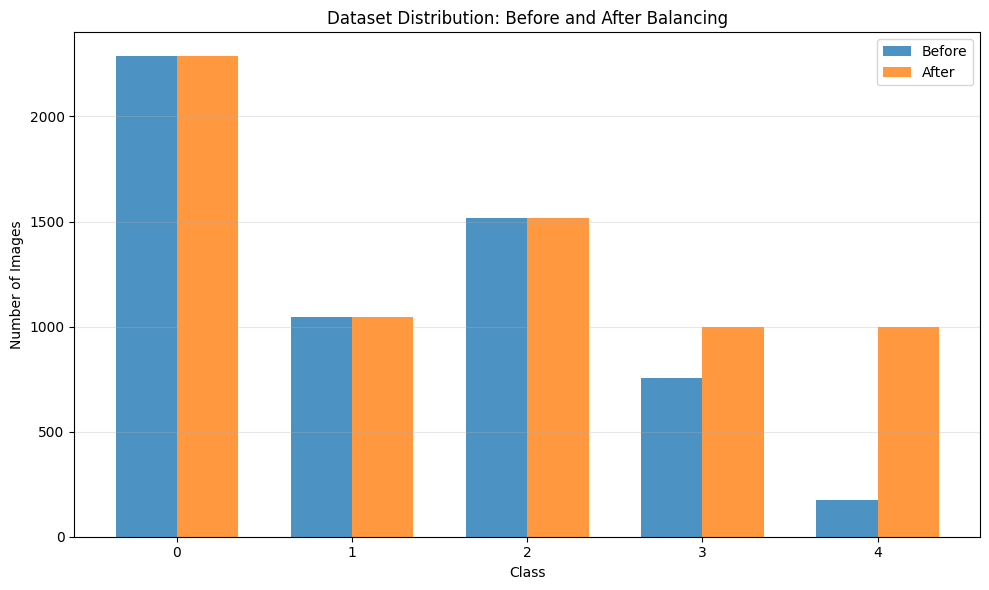


✓ Dataset balancing complete!
Balanced dataset saved to: /content/balanced_dataset


In [ ]:
# ============================================
# MAIN EXECUTION
# ============================================

DATASET_PATH = '/content/train'
BALANCED_PATH = '/content/balanced_dataset'
TARGET_IMAGES_PER_CLASS = 1000

# Analyze original dataset
print("=" * 50)
print("ANALYZING ORIGINAL DATASET")
print("=" * 50)
before_counts = analyze_dataset(DATASET_PATH)

# Balance the dataset
print("\n" + "=" * 50)
print("BALANCING DATASET")
print("=" * 50)
balance_dataset(DATASET_PATH, BALANCED_PATH, target_count=TARGET_IMAGES_PER_CLASS)

# Analyze balanced dataset
print("\n" + "=" * 50)
print("ANALYZING BALANCED DATASET")
print("=" * 50)
after_counts = analyze_dataset(BALANCED_PATH)

# Visualize the results
plot_distribution(before_counts, after_counts)

print("\n✓ Dataset balancing complete!")
print(f"Balanced dataset saved to: {BALANCED_PATH}")

In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/balanced_dataset",
    labels="inferred",        # 🔥 automatic labeling
    label_mode="int",         # integer labels (0,1,2,3,4)
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)


Found 6848 files belonging to 5 classes.


In [ ]:
import tensorflow as tf

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/val",
    labels="inferred",        # 🔥 automatic labeling
    label_mode="int",         # integer labels (0,1,2,3,4)
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)


Found 826 files belonging to 5 classes.


In [ ]:
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,      # ❗ removes ImageNet classifier
    weights="imagenet"
)

base_model.trainable = True  # 🔒 freeze feature extractor

for layer in base_model.layers[:-30]:
    layer.trainable = False


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:

preprocess = tf.keras.applications.mobilenet_v3.preprocess_input


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = preprocess(inputs)                 # correct normalization
x = base_model(x, training=True)      # feature extraction
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)    # helps overfitting

outputs = tf.keras.layers.Dense(
    5, activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)



In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,

)


Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 50s 111ms/step - accuracy: 0.3857 - loss: 1.4601 - val_accuracy: 0.4056 - val_loss: 1.2888
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.5864 - loss: 0.9821 - val_accuracy: 0.4939 - val_loss: 1.1442
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.6687 - loss: 0.8064 - val_accuracy: 0.5375 - val_loss: 1.0672
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7073 - loss: 0.7098 - val_accuracy: 0.5557 - val_loss: 1.0298
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.7505 - loss: 0.6137 - val_accuracy: 0.5678 - val_loss: 1.0086
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.7958 - loss: 0.5285 - val_accuracy: 0.5908 - val_loss: 0.9921
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8410 - loss: 0.4255 - val_accuracy: 0.5944 - val_loss: 1.0174
Epoch 8/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8726 - loss: 0.3454 - val

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/test",
    labels="inferred",
    label_mode="int",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)


Found 1656 files belonging to 5 classes.


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")


52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 227ms/step - accuracy: 0.6185 - loss: 2.4679
Test Accuracy: 0.5429


In [ ]:
import numpy as np

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[229  59  36   3   1]
 [ 79  40  29   5   0]
 [ 52  43 103  13   1]
 [  6   9  17  56  18]
 [  0   1   1   3  22]]


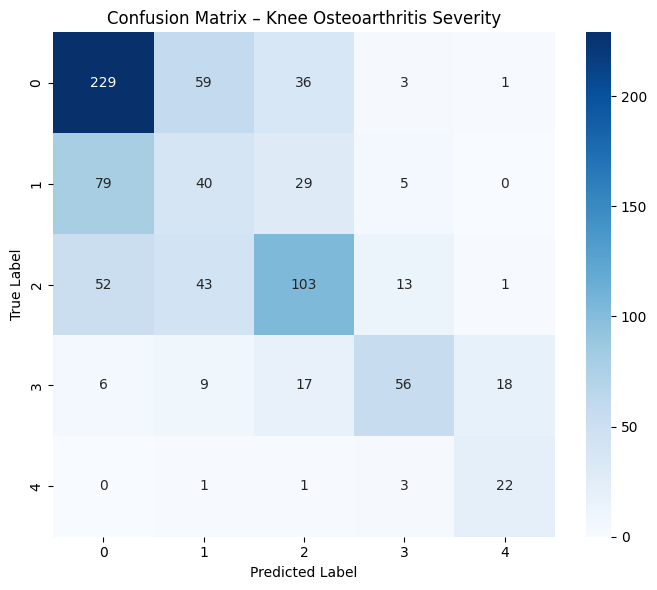

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = val_ds.class_names

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Knee Osteoarthritis Severity")
plt.tight_layout()
plt.show()


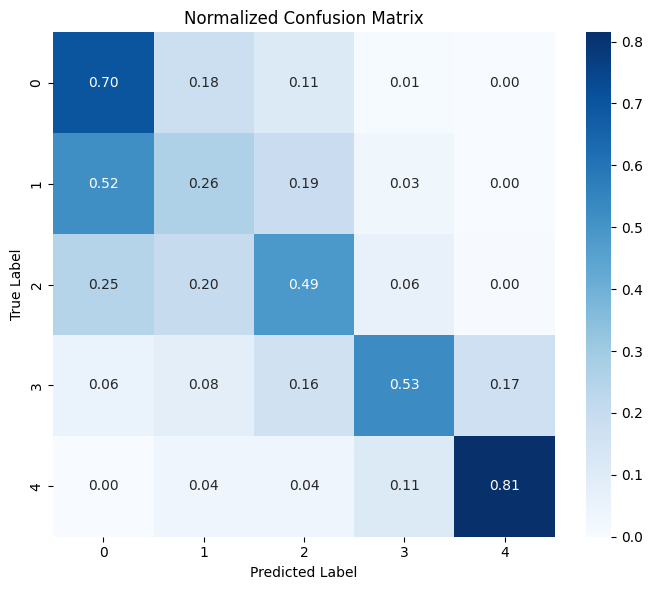

In [ ]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
class_names = train_ds.class_names
print(class_names)


['0', '1', '2', '3', '4']


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)

def predict_single_image(image_path, model, class_names):
    # Load image
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    # Convert to array
    img_array = tf.keras.utils.img_to_array(img)

    # Expand dimensions (1, 224, 224, 3)
    img_array = tf.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]
    confidence = np.max(predictions)

    # Display image
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted Class: {class_names[predicted_class]} "
        f"(Confidence: {confidence:.2f})"
    )
    plt.show()

    return class_names[predicted_class], confidence


In [ ]:
image_path = "/content/train/1/9002316R.png"  # change this
predicted_class, confidence = predict_single_image(
    image_path,
    model,
    class_names
)

print("Predicted OA Grade:", predicted_class)
print("Confidence:", confidence)


In [ ]:
severity_map = {
    "0": "No Osteoarthritis",
    "1": "Doubtful OA",
    "2": "Mild OA",
    "3": "Moderate OA",
    "4": "Severe OA"
}

print("Diagnosis:", severity_map[predicted_class])


Diagnosis: Doubtful OA


In [ ]:
model.save("model.keras")


In [ ]:
model = tf.keras.models.load_model("model.keras")
